# Ensembling and Stacking

Notebooks 5, 7, 8 and 9 each selected a best configuration for one approach:

| Approach | Notebook |
|---|---|
| SARIMAX | 5 |
| Local ML (one model on the total) | 7 |
| Global ML (one model on a panel, total bottom-up) | 8 |
| TimesFM (zero-shot foundation model) | 9 |

The four approaches make different kinds of errors, so **combining** their forecasts can beat each
of them. This notebook tests three simple combinations of the four best forecasts:

| Strategy | How the combined forecast is built | Parameters learned |
|---|---|---|
| **Mean** | average of the four forecasts, month by month | none |
| **Median** | median of the four forecasts, month by month (with four members, the mean of the middle two) | none |
| **Inverse-MASE mean** | weighted mean, each model weighted by 1 / its mean seasonal MASE (the more accurate, the heavier) | none fitted: the weights come from past accuracy |
| **Huber stacking** | a Huber regression of the actual arrivals on the four forecasts, without intercept; its coefficients are the weights of each model (free: any sign, any sum) | one weight per model |
| **Linear / Ridge / Lasso stacking** | the same weighted sum with the weights constrained to be **≥ 0** (`positive=True`) and a squared-error loss, fitted with no penalty (linear regression), an L2 penalty (Ridge) or an L1 penalty that can drop a model (Lasso) | one weight per model (+ the penalty for Ridge and Lasso) |

Mean and median are the classic **ensembles**: no parameters, so nothing to overfit. **Stacking**
learns how much to trust each model from their past forecasts (Joseph & Tackes, *Modern Time
Series Forecasting with Python*, chapter on ensembling and stacking). The Huber loss is quadratic
for small errors and linear for large ones, so a few months with very large misses (such as the
2025 jump) do not dominate the weights.

**Everything is evaluated on validation data only.** The inputs are the forecasts of the four best
configurations at the four validation origins of notebooks 5–9 (4 × 12 = 48 months). The test
set is never read here.

## Setup

In [30]:
import json
import logging
import os
import tempfile
import warnings

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display
from sklearn.linear_model import (
    HuberRegressor,
    LassoCV,
    LinearRegression,
    Ridge,
)
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut

load_dotenv()

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-04-01')  # first pandemic month: April 2020
COVID_END = pd.Timestamp('2021-12-31')
SEASONAL_PERIOD = 12
TARGET = 'arrival_count'
FREQ = 'ME'

sns.set_palette('colorblind')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
logging.getLogger('mlflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=FutureWarning)
mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI'))
client = mlflow.MlflowClient()
EXPERIMENT_NAME = 'Brazil Tourism Forecasting Ensembles'
experiment = mlflow.set_experiment(EXPERIMENT_NAME)

## 1. The Best Forecast of Each Approach

Each of notebooks 5, 7, 8 and 9 ends by logging the forecasts of its best configuration at every
validation origin (artifact `validation_forecasts.csv`, run tag
`role = best_validation_forecasts`). They are read from MLflow here; the most recent run of each
experiment is used. The notebooks must have been run up to that final section first.

In [31]:
EXPERIMENTS = {
    'SARIMAX': 'Brazil Tourism Forecasting ARIMA',
    'Local ML': 'Brazil Tourism Forecasting ML',
    'Global ML': 'Brazil Tourism Forecasting ML Global',
    'TimesFM': 'Brazil Tourism Forecasting TimesFM',
}
APPROACHES = list(EXPERIMENTS)


def load_best_forecasts(approach, experiment_name):
    """The latest `best_validation_forecasts` run of an experiment and its forecasts."""
    found = mlflow.get_experiment_by_name(experiment_name)
    assert found is not None, f'{approach}: run its notebook first ({experiment_name})'
    runs = client.search_runs(
        [found.experiment_id],
        filter_string="tags.role = 'best_validation_forecasts'",
        order_by=['attributes.start_time DESC'],
        max_results=1,
    )
    assert runs, f'{approach}: run the last section of its notebook first'
    path = mlflow.artifacts.download_artifacts(
        run_id=runs[0].info.run_id,
        artifact_path='validation_forecasts.csv',
        dst_path=tempfile.mkdtemp(),
    )
    return runs[0], pd.read_csv(path, parse_dates=['date'])


members, frames = {}, {}
for approach, experiment_name in EXPERIMENTS.items():
    run, frames[approach] = load_best_forecasts(approach, experiment_name)
    members[approach] = {
        'configuration': run.data.params['configuration'],
        'MASE_mean (logged)': run.data.metrics['MASE_mean'],
        'origins': run.data.params['origins'],
    }

# one row per (origin, month), one column per approach
forecasts = pd.concat(
    {a: f.set_index(['origin', 'date'])['forecast'] for a, f in frames.items()}, axis=1
)
forecasts['actual'] = frames[APPROACHES[0]].set_index(['origin', 'date'])['actual']
for approach, frame in frames.items():
    actual = frame.set_index(['origin', 'date'])['actual']
    assert np.allclose(actual, forecasts['actual']), f'{approach}: different actuals'
assert not forecasts.isna().any().any(), 'the approaches cover different months'

ORIGIN_LABELS = sorted(forecasts.index.get_level_values('origin').unique())
print(f'{len(forecasts)} validation months at origins {ORIGIN_LABELS}')
pd.DataFrame(members).T

48 validation months at origins ['2017-08', '2018-08', '2023-08', '2024-08']


,configuration,MASE_mean (logged),origins
SARIMAX,"SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_recov...",0.992006,"2017-08, 2018-08, 2023-08, 2024-08"
Local ML,XGBoost | seasonal_log_diff | last_4y | keep |...,0.98228,"2017-08, 2018-08, 2023-08, 2024-08"
Global ML,XGBoost | seasonal_log_diff | last_6y | keep |...,1.101019,"2017-08, 2018-08, 2023-08, 2024-08"
TimesFM,all | remove | none | calendar | symmetric,1.31229,"2017-08, 2018-08, 2023-08, 2024-08"


## 2. Scoring

The scoring of notebooks 5–9, recomputed from the forecasts: at each origin RMSE, MAE, MAPE, R²,
Forecast Bias (`(Σy − Σŷ) / Σy × 100`, positive = under-forecast) and the **seasonal MASE** (MAE
divided by the in-sample MAE of the seasonal naive on the history up to the origin, pandemic pairs
from April 2020 to December 2022 left out). The origins are combined into `MASE_mean` (the ranking
metric), `MASE_worst` and `MASE_post`; the other metrics are those of the latest origin, the
validation year.

As a check, the `MASE_mean` recomputed here for each approach must match the value logged by its
notebook. The seasonal naive is recomputed at every origin as the baseline.

In [32]:
def load_monthly(file_name):
    raw = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, file_name))
    return raw.set_index('date')[TARGET].resample(FREQ).sum()


# train + validation (the test set is never read)
full_series = pd.concat([load_monthly('train.parquet'), load_monthly('val.parquet')])
MASE_EXCLUDED = (COVID_START, pd.Timestamp('2022-12-31'))


def origin_date(label):
    return pd.Timestamp(label) + pd.offsets.MonthEnd(0)


ORIGINS = {label: origin_date(label) for label in ORIGIN_LABELS}
LATEST = ORIGIN_LABELS[-1]  # its validation window is val.parquet
POST_COVID = [label for label, origin in ORIGINS.items() if origin > COVID_END]


def seasonal_mase_scale(history):
    """In-sample MAE of the seasonal naive (y_t - y_{t-12}), pandemic pairs excluded."""
    diffs = (history - history.shift(SEASONAL_PERIOD)).abs()
    in_pandemic = history.index.to_series().between(*MASE_EXCLUDED)
    touches = in_pandemic | in_pandemic.shift(SEASONAL_PERIOD, fill_value=False)
    return float(diffs[~touches.to_numpy()].mean())


MASE_SCALES = {
    label: seasonal_mase_scale(full_series.loc[:origin])
    for label, origin in ORIGINS.items()
}
METRICS = ['RMSE', 'MAE', 'MAPE', 'R2', 'MASE', 'Forecast Bias']


def score(actual, predicted, label):
    actual, predicted = np.asarray(actual, float), np.asarray(predicted, float)
    errors = actual - predicted
    mae = float(np.mean(np.abs(errors)))
    return {
        'RMSE': float(np.sqrt(np.mean(errors**2))),
        'MAE': mae,
        'MAPE': float(np.mean(np.abs(errors / actual)) * 100),
        'R2': float(r2_score(actual, predicted)),
        'MASE': mae / MASE_SCALES[label],
        'Forecast Bias': float((actual.sum() - predicted.sum()) / actual.sum() * 100),
    }


def evaluate(predicted):
    """Scores of one forecast Series (indexed like `forecasts`) at every origin."""
    per_origin = {
        label: score(forecasts.loc[label, 'actual'], predicted.loc[label], label)
        for label in ORIGIN_LABELS
    }
    mase = pd.Series({label: s['MASE'] for label, s in per_origin.items()})
    return {
        **{f'MASE {label}': value for label, value in mase.items()},
        'MASE_mean': float(mase.mean()),
        'MASE_worst': float(mase.max()),
        'MASE_post': float(mase[POST_COVID].mean()),
        **per_origin[LATEST],
    }


# seasonal naive: the same month one year earlier, at every origin
seasonal_naive = pd.Series(
    [full_series.get(date - pd.offsets.MonthEnd(12)) for _, date in forecasts.index],
    index=forecasts.index,
)

results = {'seasonal naive': evaluate(seasonal_naive)}
for approach in APPROACHES:
    results[approach] = evaluate(forecasts[approach])
    logged = members[approach]['MASE_mean (logged)']
    assert np.isclose(results[approach]['MASE_mean'], logged), (approach, logged)
print('Recomputed MASE_mean matches the value logged by every notebook')
pd.DataFrame(results).T.round(3)

Recomputed MASE_mean matches the value logged by every notebook


,MASE 2017-08,MASE 2018-08,MASE 2023-08,MASE 2024-08,MASE_mean,MASE_worst,MASE_post,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
seasonal naive,0.680,0.977,1.463,4.024,1.786,4.024,2.743,255353.116,209126.083,26.478,0.407,4.024,28.357
SARIMAX,0.723,0.970,1.017,1.258,0.992,1.258,1.137,103693.084,65358.584,7.302,0.902,1.258,7.931
Local ML,0.756,1.063,0.932,1.179,0.982,1.179,1.055,80115.966,61259.475,7.788,0.942,1.179,-1.349
Global ML,1.308,0.591,0.943,1.563,1.101,1.563,1.253,125101.593,81214.072,9.051,0.858,1.563,9.463
TimesFM,0.912,0.701,0.808,2.829,1.312,2.829,1.818,184216.923,147015.578,17.815,0.691,2.829,19.935


## 3. Simple Ensembles: Mean, Median and Inverse-MASE Mean

No parameters are learned, so the mean and the median can be scored directly at the four
origins, exactly like the individual models.

- **Mean**: every model gets the same weight (1/4). It cancels errors that go in opposite
  directions, but a single model that goes very wrong pulls it along.
- **Median**: robust to one model going very wrong; with four members it is the mean of the two
  middle forecasts of each month.

In [33]:
ensembles = {
    'mean': forecasts[APPROACHES].mean(axis=1),
    'median': forecasts[APPROACHES].median(axis=1),
}
for name, predicted in ensembles.items():
    results[name] = evaluate(predicted)
pd.DataFrame({name: results[name] for name in ['mean', 'median']}).T.round(3)

,MASE 2017-08,MASE 2018-08,MASE 2023-08,MASE 2024-08,MASE_mean,MASE_worst,MASE_post,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
mean,0.764,0.797,0.856,1.377,0.949,1.377,1.117,111889.892,71568.901,7.778,0.886,1.377,8.995
median,0.684,0.926,0.915,1.410,0.984,1.410,1.162,114113.785,73286.328,8.177,0.882,1.410,8.697


### Inverse-MASE Weighted Mean

A middle ground between the plain mean and stacking: every model gets a weight proportional to
**1 / its mean seasonal MASE**, normalized to sum to 1. A model twice as accurate gets twice the
weight; no regression is fitted, so the weights cannot turn negative or chase noise.

`w_i = (1 / MASE_i) / Σ_j (1 / MASE_j)`

The weights are learned from the models' past accuracy, so they are evaluated like stacking,
**leaving one origin out**: the weights used for an origin come from the MASE of the four models
at the **other three** origins. The weights from all four origins are shown at the end; they are
the ones the final notebook would use.

In [34]:
def inverse_mase_weights(labels):
    """Weights proportional to 1 / mean seasonal MASE over the given origins."""
    mase = pd.Series({
        approach: np.mean([results[approach][f'MASE {label}'] for label in labels])
        for approach in APPROACHES
    })
    inverse = 1 / mase
    return inverse / inverse.sum()


inverse_mase = pd.Series(np.nan, index=forecasts.index)
inverse_mase_table = {}
for held_out in ORIGIN_LABELS:
    w = inverse_mase_weights([label for label in ORIGIN_LABELS if label != held_out])
    held = forecasts.xs(held_out, level='origin', drop_level=False)
    inverse_mase.loc[held.index] = (
        held[APPROACHES].to_numpy() @ w[APPROACHES].to_numpy()
    )
    inverse_mase_table[f'held out {held_out}'] = w

ensembles['inverse-MASE mean'] = inverse_mase
results['inverse-MASE mean'] = evaluate(inverse_mase)

final_inverse_mase_weights = inverse_mase_weights(ORIGIN_LABELS)
inverse_mase_table['all 4 origins (final)'] = final_inverse_mase_weights
display(pd.DataFrame(inverse_mase_table).T.round(3))
pd.DataFrame({
    name: results[name] for name in ['mean', 'median', 'inverse-MASE mean']
}).T.round(3)

,SARIMAX,Local ML,Global ML,TimesFM
held out 2017-08,0.262,0.268,0.274,0.196
held out 2018-08,0.286,0.300,0.225,0.189
held out 2023-08,0.286,0.281,0.244,0.190
held out 2024-08,0.246,0.243,0.235,0.276
all 4 origins (final),0.273,0.275,0.246,0.206


,MASE 2017-08,MASE 2018-08,MASE 2023-08,MASE 2024-08,MASE_mean,MASE_worst,MASE_post,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
mean,0.764,0.797,0.856,1.377,0.949,1.377,1.117,111889.892,71568.901,7.778,0.886,1.377,8.995
median,0.684,0.926,0.915,1.410,0.984,1.410,1.162,114113.785,73286.328,8.177,0.882,1.410,8.697
inverse-MASE mean,0.757,0.836,0.873,1.416,0.971,1.416,1.144,113729.239,73573.258,8.028,0.882,1.416,9.350


## 4. Stacking: Huber, Linear, Ridge and Lasso Regressions

Stacking fits a **meta-model** that takes the four forecasts of a month as its inputs and
predicts the actual value:

`actual ≈ w₁·SARIMAX + w₂·Local ML + w₃·Global ML + w₄·TimesFM`

- **Huber regression** (`sklearn.linear_model.HuberRegressor`): squared loss for small residuals
  and absolute loss beyond `epsilon` = 1.35 robust standard deviations, so a few very large misses
  do not dominate the weights.
- **No intercept**: the combination is a weighted sum of the forecasts, so it stays on the level
  of the models. The weights are not forced to be positive or to sum to 1; how far they drift from
  that is itself informative.
- Inputs and target are divided by 100,000 arrivals before fitting (numerical conditioning only;
  without an intercept this does not change the weights).

**Honest evaluation: leave one origin out.** The weights must never be learned from the months
they are scored on. For each origin, the regression is fitted on the other three origins
(36 months) and predicts the held-out one. Every origin therefore gets a stacked forecast from
weights that never saw it, and the four are scored like the other methods.

The weights fitted on **all four** origins are shown at the end: they cannot be scored on
validation data (no held-out months are left), and are the ones the final notebook would use.

In [35]:
HUBER_PARAMS = {
    'epsilon': 1.35,
    'alpha': 1e-4,
    'fit_intercept': False,
    'max_iter': 1000,
}
SCALE = 1e5


def fit_huber(rows):
    return HuberRegressor(**HUBER_PARAMS).fit(
        rows[APPROACHES] / SCALE, rows['actual'] / SCALE
    )


stacked = pd.Series(np.nan, index=forecasts.index)
fold_weights = {}
for held_out in ORIGIN_LABELS:
    train = forecasts.drop(index=held_out, level='origin')
    model = fit_huber(train)
    held = forecasts.xs(held_out, level='origin', drop_level=False)
    stacked.loc[held.index] = model.predict(held[APPROACHES] / SCALE) * SCALE
    fold_weights[f'held out {held_out}'] = dict(zip(APPROACHES, model.coef_))

ensembles['huber stacking'] = stacked
results['huber stacking'] = evaluate(stacked)

weights = pd.DataFrame(fold_weights).T
weights['sum of weights'] = weights.sum(axis=1)
final_model = fit_huber(forecasts)
weights.loc['all 4 origins (final)'] = [*final_model.coef_, final_model.coef_.sum()]
display(weights.round(3))
pd.DataFrame({'huber stacking': results['huber stacking']}).T.round(3)

,SARIMAX,Local ML,Global ML,TimesFM,sum of weights
held out 2017-08,-1.338,0.805,1.073,0.477,1.016
held out 2018-08,-0.278,0.685,0.194,0.423,1.024
held out 2023-08,-0.018,0.738,0.215,0.048,0.983
held out 2024-08,-0.615,0.704,0.105,0.812,1.007
all 4 origins (final),-0.553,0.873,0.207,0.478,1.005


,MASE 2017-08,MASE 2018-08,MASE 2023-08,MASE 2024-08,MASE_mean,MASE_worst,MASE_post,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
huber stacking,1.306,0.958,0.92,1.537,1.18,1.537,1.229,122421.637,79899.051,8.557,0.864,1.537,10.689


### Non-Negative Stacking: Linear Regression, Ridge and Lasso

The Huber weights above are free: with four strongly correlated forecasts, the regression can
give one model a large negative weight and compensate with the others. Three regressions keep the
same form (a weighted sum of the four forecasts, no intercept, squared-error loss) with every
weight constrained to be **≥ 0** (`positive=True`), so no model is "subtracted". They differ only in
how much they penalize the weights, from none to strong:

| Stacker | Penalty | Effect on the weights |
|---|---|---|
| **Linear regression** | none | non-negative least squares, the classic stacking of Breiman; nothing shrinks the weights |
| **Ridge** | L2 (`alpha · Σw²`) | shrinks every weight towards zero, keeps all models |
| **Lasso** | L1 (`alpha · Σ|w|`) | shrinks and can set a weight to exactly 0, dropping a model |

The weights are not forced to sum to 1; their sum shows whether the combination shifts the level
of the forecasts. For Ridge and Lasso the penalty is chosen by a **leave-one-origin-out**
cross-validation **inside** the training origins, so the held-out origin of the outer loop is used
neither for the weights nor for the penalty (nested validation). The evaluation is the same
leave-one-origin-out scheme as the Huber stacking.

In [36]:
RIDGE_ALPHAS = np.logspace(-3, 3, 13)


def inner_splits(rows):
    """Leave-one-origin-out splits inside the training origins (for the penalty)."""
    origins = rows.index.get_level_values('origin')
    return list(LeaveOneGroupOut().split(rows, groups=origins))


def fit_linear(rows):
    """Non-negative least squares: no penalty, so no alpha to choose."""
    model = LinearRegression(positive=True, fit_intercept=False)
    return model.fit(rows[APPROACHES] / SCALE, rows['actual'] / SCALE), np.nan


def fit_ridge(rows):
    search = GridSearchCV(
        Ridge(positive=True, fit_intercept=False),
        {'alpha': RIDGE_ALPHAS},
        cv=inner_splits(rows),
        scoring='neg_mean_squared_error',
    ).fit(rows[APPROACHES] / SCALE, rows['actual'] / SCALE)
    return search.best_estimator_, search.best_params_['alpha']


def fit_lasso(rows):
    model = LassoCV(
        alphas=50,
        positive=True,
        fit_intercept=False,
        cv=inner_splits(rows),
        max_iter=10000,
    ).fit(rows[APPROACHES] / SCALE, rows['actual'] / SCALE)
    return model, model.alpha_


NON_NEGATIVE_STACKERS = {
    'linear stacking': fit_linear,
    'ridge stacking': fit_ridge,
    'lasso stacking': fit_lasso,
}
final_stackers = {}
for name, fit in NON_NEGATIVE_STACKERS.items():
    stacked_forecast = pd.Series(np.nan, index=forecasts.index)
    fold_table = {}
    for held_out in ORIGIN_LABELS:
        model, alpha = fit(forecasts.drop(index=held_out, level='origin'))
        held = forecasts.xs(held_out, level='origin', drop_level=False)
        stacked_forecast.loc[held.index] = (
            model.predict(held[APPROACHES] / SCALE) * SCALE
        )
        fold_table[f'held out {held_out}'] = {
            **dict(zip(APPROACHES, model.coef_)),
            'alpha': alpha,
        }
    ensembles[name] = stacked_forecast
    results[name] = evaluate(stacked_forecast)

    final_stackers[name] = fit(forecasts)
    final_fit, final_alpha = final_stackers[name]
    fold_table['all 4 origins (final)'] = {
        **dict(zip(APPROACHES, final_fit.coef_)),
        'alpha': final_alpha,
    }
    table = pd.DataFrame(fold_table).T
    table.insert(len(APPROACHES), 'sum of weights', table[APPROACHES].sum(axis=1))
    print(name)
    display(table.round(3))

STACKERS = ['huber stacking', *NON_NEGATIVE_STACKERS]
pd.DataFrame({name: results[name] for name in STACKERS}).T.round(3)

linear stacking


,SARIMAX,Local ML,Global ML,TimesFM,sum of weights,alpha
held out 2017-08,0.0,0.538,0.468,0.000,1.006,NaN
held out 2018-08,0.0,0.657,0.133,0.243,1.033,NaN
held out 2023-08,0.0,0.678,0.322,0.000,1.000,NaN
held out 2024-08,0.0,0.274,0.279,0.449,1.002,NaN
all 4 origins (final),0.0,0.666,0.327,0.005,0.997,NaN


ridge stacking


,SARIMAX,Local ML,Global ML,TimesFM,sum of weights,alpha
held out 2017-08,0.214,0.331,0.296,0.180,1.022,31.623
held out 2018-08,0.246,0.335,0.233,0.237,1.051,31.623
held out 2023-08,0.000,0.678,0.322,0.000,1.000,0.001
held out 2024-08,0.213,0.254,0.256,0.263,0.986,31.623
all 4 origins (final),0.218,0.346,0.276,0.180,1.021,31.623


lasso stacking


,SARIMAX,Local ML,Global ML,TimesFM,sum of weights,alpha
held out 2017-08,0.0,0.933,0.000,0.0,0.933,1.484
held out 2018-08,0.0,0.955,0.000,0.0,0.955,1.316
held out 2023-08,0.0,0.746,0.237,0.0,0.983,0.373
held out 2024-08,0.0,0.810,0.100,0.0,0.910,1.550
all 4 origins (final),0.0,0.861,0.092,0.0,0.953,0.933


,MASE 2017-08,MASE 2018-08,MASE 2023-08,MASE 2024-08,MASE_mean,MASE_worst,MASE_post,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
huber stacking,1.306,0.958,0.920,1.537,1.180,1.537,1.229,122421.637,79899.051,8.557,0.864,1.537,10.689
linear stacking,0.758,1.133,0.904,1.600,1.099,1.600,1.252,124142.486,83160.743,9.130,0.860,1.600,11.002
ridge stacking,0.717,1.206,0.904,1.545,1.093,1.545,1.225,120706.150,80318.891,8.914,0.867,1.545,10.394
lasso stacking,0.753,0.927,0.939,1.503,1.031,1.503,1.221,115772.913,78132.373,8.549,0.878,1.503,8.854


## 5. Results

All methods on the same four validation origins, ranked by mean seasonal MASE. The dashed line is
the seasonal naive; the best single model is the reference an ensemble has to beat to be worth
its extra complexity.

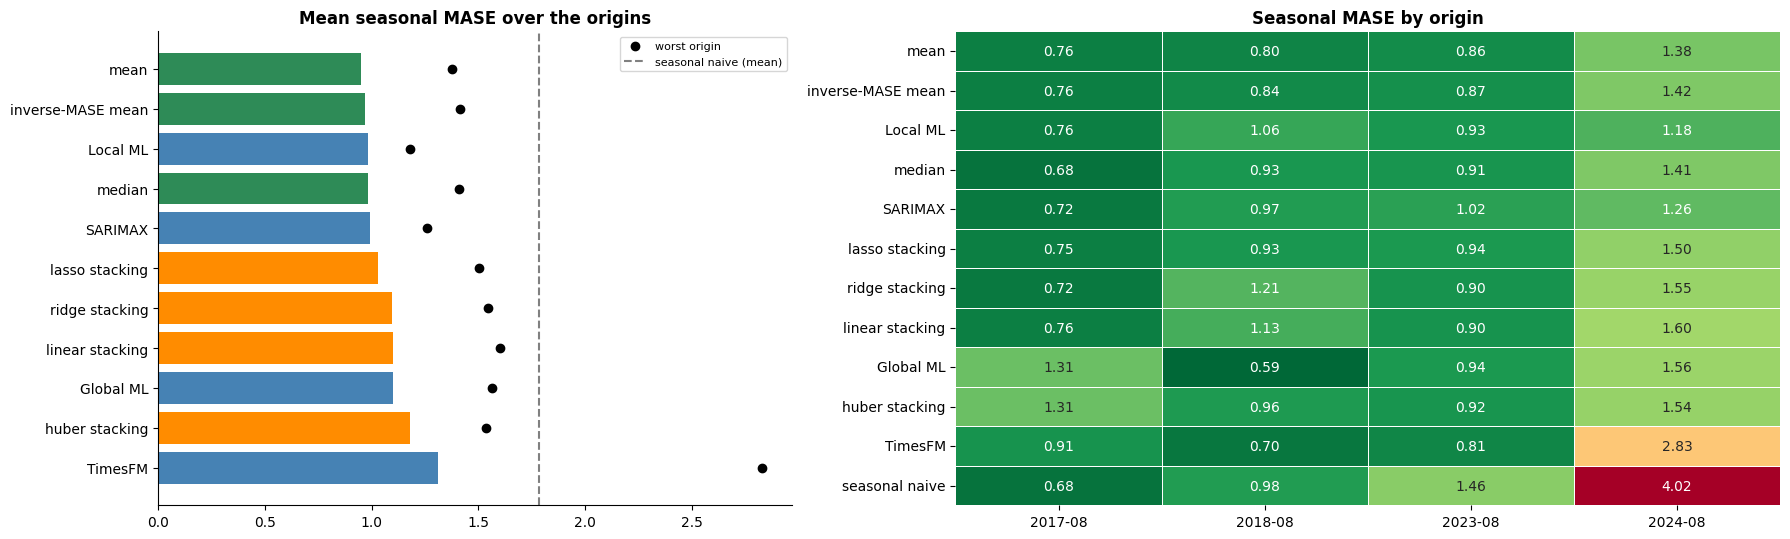

,kind,MASE 2017-08,MASE 2018-08,MASE 2023-08,MASE 2024-08,MASE_mean,MASE_worst,MASE_post,RMSE,MAPE,R2,Forecast Bias,beats best single
mean,ensemble,0.764,0.797,0.856,1.377,0.949,1.377,1.117,111889.892,7.778,0.886,8.995,True
inverse-MASE mean,ensemble,0.757,0.836,0.873,1.416,0.971,1.416,1.144,113729.239,8.028,0.882,9.350,True
Local ML,single model,0.756,1.063,0.932,1.179,0.982,1.179,1.055,80115.966,7.788,0.942,-1.349,False
median,ensemble,0.684,0.926,0.915,1.410,0.984,1.410,1.162,114113.785,8.177,0.882,8.697,False
SARIMAX,single model,0.723,0.970,1.017,1.258,0.992,1.258,1.137,103693.084,7.302,0.902,7.931,False
lasso stacking,stacking,0.753,0.927,0.939,1.503,1.031,1.503,1.221,115772.913,8.549,0.878,8.854,False
ridge stacking,stacking,0.717,1.206,0.904,1.545,1.093,1.545,1.225,120706.150,8.914,0.867,10.394,False
linear stacking,stacking,0.758,1.133,0.904,1.600,1.099,1.600,1.252,124142.486,9.130,0.860,11.002,False
Global ML,single model,1.308,0.591,0.943,1.563,1.101,1.563,1.253,125101.593,9.051,0.858,9.463,False
huber stacking,stacking,1.306,0.958,0.920,1.537,1.180,1.537,1.229,122421.637,8.557,0.864,10.689,False


In [37]:
KIND = {
    **dict.fromkeys(APPROACHES, 'single model'),
    'mean': 'ensemble',
    'median': 'ensemble',
    'inverse-MASE mean': 'ensemble',
    'huber stacking': 'stacking',
    'linear stacking': 'stacking',
    'ridge stacking': 'stacking',
    'lasso stacking': 'stacking',
    'seasonal naive': 'baseline',
}
COLORS = {
    'single model': 'steelblue',
    'ensemble': 'seagreen',
    'stacking': 'darkorange',
    'baseline': 'grey',
}
summary = pd.DataFrame(results).T.sort_values('MASE_mean')
summary.insert(0, 'kind', summary.index.map(KIND))
best_single = summary[summary['kind'] == 'single model'].index[0]
summary['beats best single'] = (
    summary['MASE_mean'] < summary.loc[best_single, 'MASE_mean']
)

fig, axes = plt.subplots(
    1, 2, figsize=(18, 5.5), gridspec_kw={'width_ratios': [1, 1.3]}
)
ranked = summary.drop(index='seasonal naive')
axes[0].barh(
    ranked.index[::-1],
    ranked['MASE_mean'][::-1],
    color=[COLORS[k] for k in ranked['kind'][::-1]],
)
axes[0].scatter(
    ranked['MASE_worst'][::-1],
    ranked.index[::-1],
    color='black',
    zorder=3,
    label='worst origin',
)
axes[0].axvline(
    summary.loc['seasonal naive', 'MASE_mean'],
    color='grey',
    linestyle='--',
    label='seasonal naive (mean)',
)
axes[0].set_title('Mean seasonal MASE over the origins', fontweight='bold')
axes[0].legend(fontsize=8)
sns.despine(ax=axes[0])

origin_columns = [f'MASE {label}' for label in ORIGIN_LABELS]
sns.heatmap(
    summary[origin_columns].astype(float),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    linewidths=0.4,
    cbar=False,
    ax=axes[1],
)
axes[1].set_title('Seasonal MASE by origin', fontweight='bold')
axes[1].set_xticklabels(ORIGIN_LABELS)
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

summary[
    [
        'kind',
        *origin_columns,
        'MASE_mean',
        'MASE_worst',
        'MASE_post',
        'RMSE',
        'MAPE',
        'R2',
        'Forecast Bias',
        'beats best single',
    ]
].round(3)

### Validation-Year Forecasts

The same view as notebooks 5–9 for the validation year (the latest origin): the last 24 months
before it, the actual year and the forecast of each combination, next to the best single model.

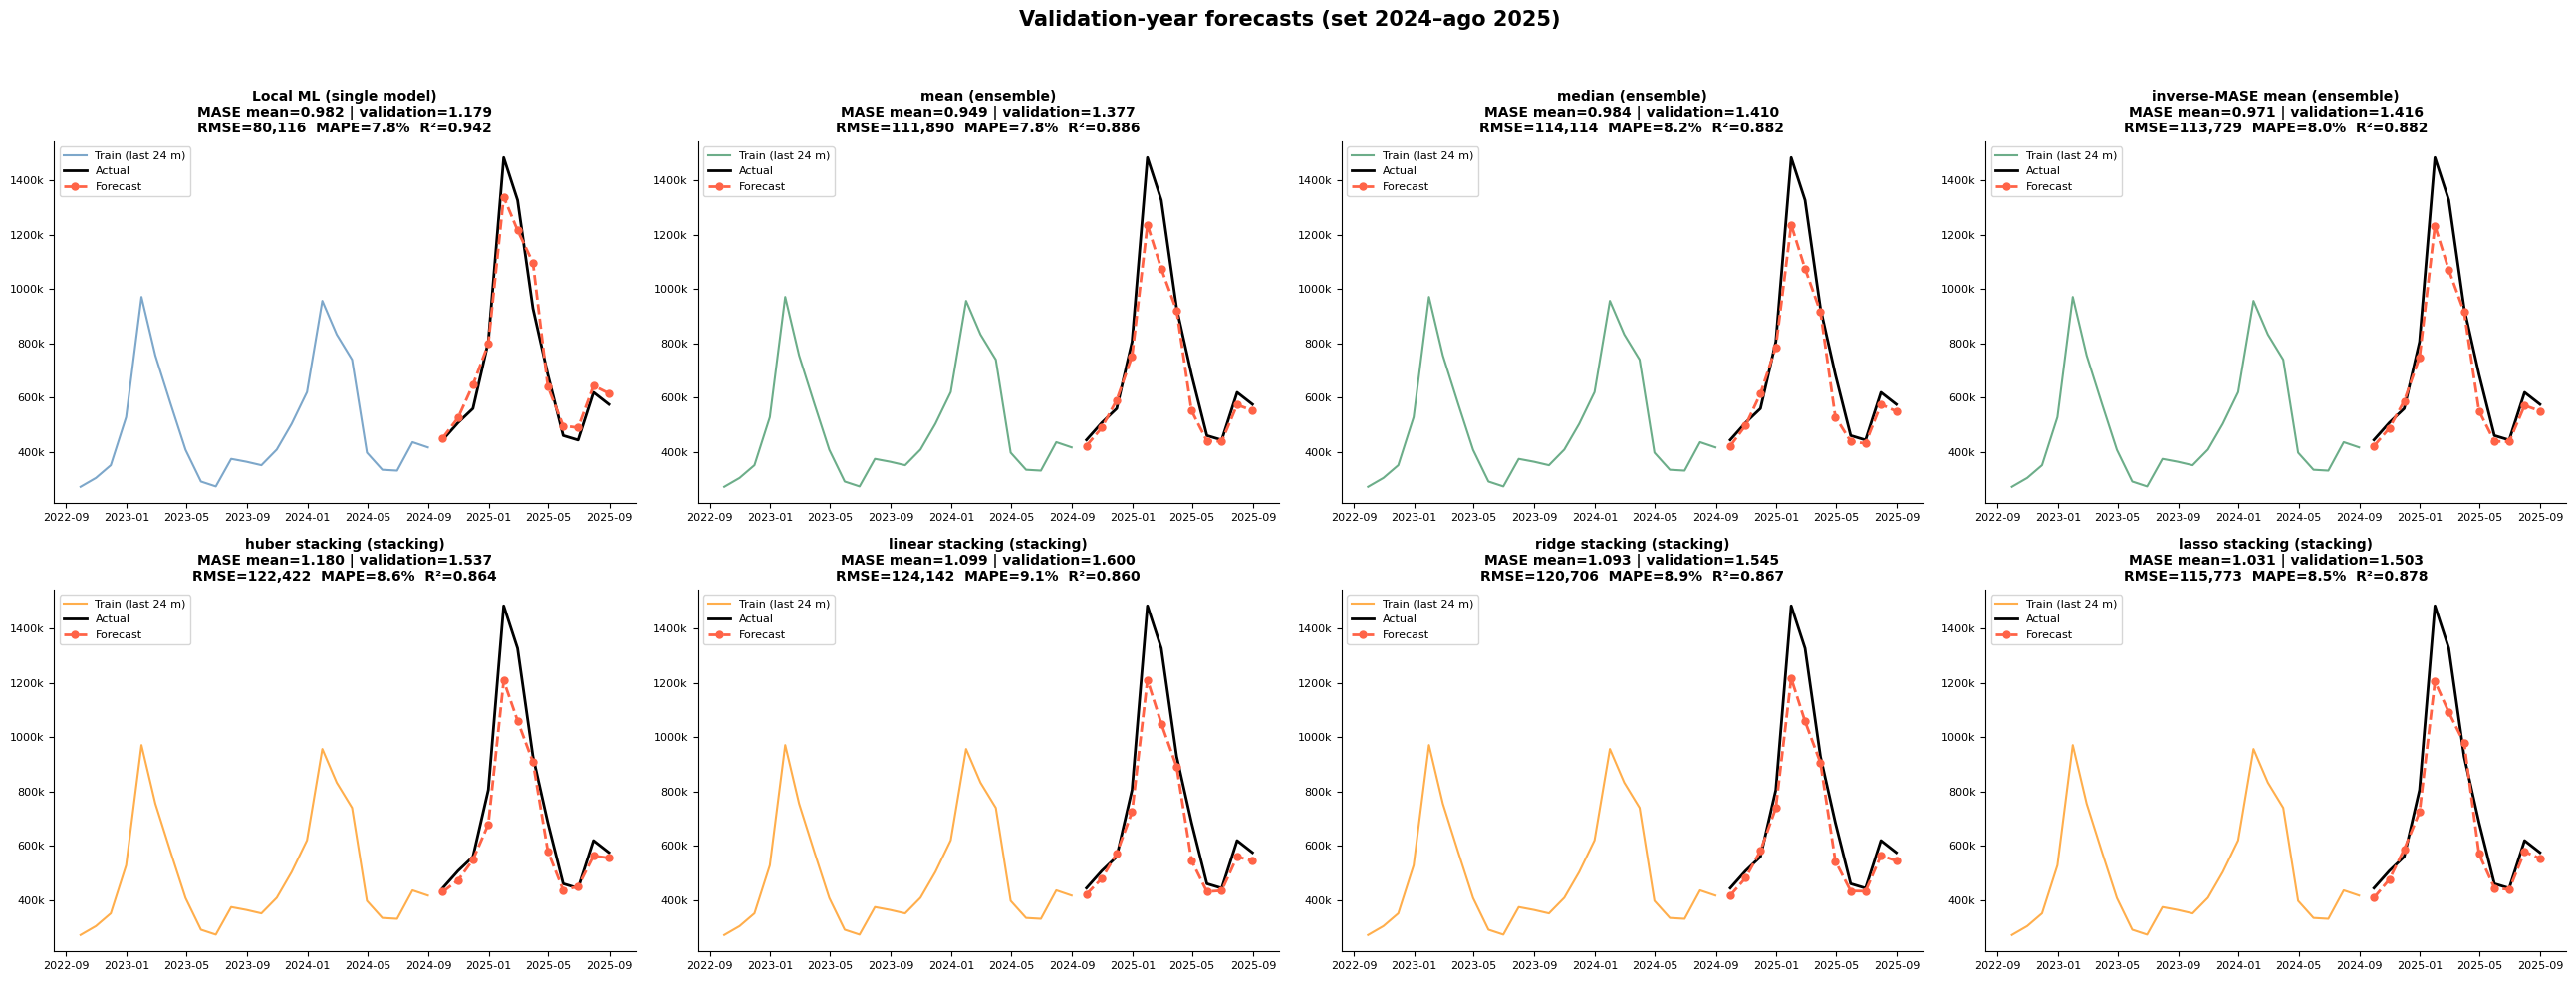

In [38]:
PANELS = [best_single, 'mean', 'median', 'inverse-MASE mean', *STACKERS]
latest = forecasts.xs(LATEST, level='origin')
history = full_series.loc[: ORIGINS[LATEST]].iloc[-24:]

fig, axes = plt.subplots(2, 4, figsize=(26, 10))
fig.suptitle(
    f'Validation-year forecasts ({latest.index[0]:%b %Y}–{latest.index[-1]:%b %Y})',
    fontsize=15,
    fontweight='bold',
)
for ax, name in zip(axes.flat, PANELS):
    predicted = (
        latest[name]
        if name in APPROACHES
        else ensembles[name].xs(LATEST, level='origin')
    )
    row = summary.loc[name]
    ax.plot(
        history.index,
        history.values,
        color=COLORS[KIND[name]],
        alpha=0.7,
        label='Train (last 24 m)',
    )
    ax.plot(latest.index, latest['actual'], color='black', linewidth=2, label='Actual')
    ax.plot(
        latest.index,
        predicted,
        color='tomato',
        linestyle='--',
        marker='o',
        markersize=5,
        linewidth=2,
        label='Forecast',
    )
    ax.set_title(
        f'{name} ({KIND[name]})\n'
        f'MASE mean={row["MASE_mean"]:.3f} | validation={row["MASE"]:.3f}\n'
        f'RMSE={row["RMSE"]:,.0f}  MAPE={row["MAPE"]:.1f}%  R²={row["R2"]:.3f}',
        fontsize=10,
        fontweight='bold',
    )
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x / 1000)}k'))
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 6. Log to MLflow

One run per combination (mean, median, inverse-MASE mean and the four stacking regressions) in the experiment **Brazil Tourism
Forecasting Ensembles**, with the members' configurations and, for stacking, the weights of each
fold and of the final fit as parameters, and the same metrics as the other notebooks
(`eval_split = validation`). Each run also stores its validation forecasts as the artifact
`validation_forecasts.csv` (tag `role = ensemble_validation_forecasts`, `kind` = ensemble or
stacking) for the validation overview notebook; for the weighted methods these are the
leave-one-origin-out forecasts.

In [39]:
def finite(value):
    return isinstance(value, (int, float, np.number)) and np.isfinite(value)


for name in ['mean', 'median', 'inverse-MASE mean', *STACKERS]:
    params = {
        'method': name,
        'members': ', '.join(APPROACHES),
        **{f'member_{a}': members[a]['configuration'][:500] for a in APPROACHES},
        'eval_split': 'validation',
        'origins': ', '.join(ORIGIN_LABELS),
        'selection_metric': 'mean_seasonal_mase',
    }
    if name == 'huber stacking':
        params['huber_params'] = json.dumps(HUBER_PARAMS)
        params['evaluation'] = 'leave one origin out'
        params['final_weights'] = json.dumps(
            dict(zip(APPROACHES, np.round(final_model.coef_, 4).tolist()))
        )
    if name == 'inverse-MASE mean':
        params['evaluation'] = 'leave one origin out'
        params['final_weights'] = json.dumps(
            final_inverse_mase_weights.round(4).to_dict()
        )
    if name in final_stackers:
        final_fit, final_alpha = final_stackers[name]
        params['evaluation'] = (
            'leave one origin out (penalty: nested leave one origin out)'
        )
        params['final_alpha'] = final_alpha
        params['final_weights'] = json.dumps(
            dict(zip(APPROACHES, np.round(final_fit.coef_, 4).tolist()))
        )
    # the validation forecasts (leave-one-origin-out for the weighted methods), in the
    # same format as the best-configuration forecasts of notebooks 5-9
    validation_forecasts = (
        forecasts[['actual']].assign(forecast=ensembles[name]).reset_index()
    )
    with mlflow.start_run(run_name=f'ensemble | {name}'):
        mlflow.set_tags({'role': 'ensemble_validation_forecasts', 'kind': KIND[name]})
        mlflow.log_params(params)
        mlflow.log_metrics({
            key.replace(' ', '_'): float(value)
            for key, value in results[name].items()
            if finite(value)
        })
        mlflow.log_text(
            validation_forecasts.to_csv(index=False), 'validation_forecasts.csv'
        )
print(f'Logged {3 + len(STACKERS)} runs to "{EXPERIMENT_NAME}"')

Logged 7 runs to "Brazil Tourism Forecasting Ensembles"


## Reading the Results

| Question | Where |
|---|---|
| Does combining the approaches beat the best single model? | `beats best single` in section 5 |
| Mean or median? | Section 3; the median resists one model going very wrong |
| Does weighting by past accuracy beat equal weights? | `inverse-MASE mean` vs `mean` (section 3 and 5) |
| Does learning weights (stacking) beat equal weights? | the four stacking rows vs `mean` in section 5 |
| Free weights or non-negative weights? | `huber stacking` vs the non-negative stackers, and the weights tables of section 4 |
| How much penalty do the weights need? | `linear` (none) vs `ridge` (L2) vs `lasso` (L1), and their `alpha` per fold |
| Which models does stacking trust, and which does it drop? | The weights tables of section 4 (per fold and final); a Lasso weight of 0 drops a model |
| Is the combination stable across origins? | `MASE_worst` and the heatmap by origin |

Things to keep in mind:

- **Few points for stacking.** The weights are learned from 36 months per fold, and the four
  forecasts are strongly correlated (they miss the same months), so the weights are uncertain:
  large weights of opposite signs, or weights that change a lot between folds, are signs of it.
  If stacking does not clearly beat the mean, the simpler mean is the safer choice.
- **Double use of the validation data.** The members were **selected** on the same four origins
  they are combined on, so every result here is somewhat optimistic; the leave-one-origin-out
  scheme only protects the stacking weights. The unbiased comparison of single models and
  combinations is the test year, in the final notebook.
- **Mean and median need no fitting**, so for the final notebook they only need the refitted
  members' test forecasts; stacking also uses the final weights of section 4.